**Dataset Preperation**

In [4]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from collections import Counter

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Copy and unzip the dataset
!cp "/content/drive/MyDrive/Intro to CV/skin_cancer.zip" /content/
!unzip -q -o /content/skin_cancer.zip -d /content/dataset/

# 3. Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 4. Locate Train/Test directories dynamically
base_dir = '/content/dataset'
for root, dirs, files in os.walk(base_dir):
    if 'Train' in dirs and 'Test' in dirs:
        base_dir = root
        break

# 5. Baseline Transforms (ImageNet standard)
baseline_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 6. Load Datasets
train_data = datasets.ImageFolder(os.path.join(base_dir, 'Train'), transform=baseline_transform)
test_data = datasets.ImageFolder(os.path.join(base_dir, 'Test'), transform=baseline_transform)

# 7. DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# 8. Extract class distribution (Required for Additional Analysis)
train_classes = dict(Counter(train_data.targets))
class_names = train_data.classes

print(f"Dataset successfully loaded on {device}!")
print(f"Number of classes: {len(class_names)}")
print("\nTrain Set: ")
for cls_idx, count in sorted(train_classes.items()):
    print(f"- {class_names[cls_idx]}: {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset successfully loaded on cuda!
Number of classes: 9

Train Set: 
- actinic keratosis: 114 images
- basal cell carcinoma: 376 images
- dermatofibroma: 95 images
- melanoma: 438 images
- nevus: 357 images
- pigmented benign keratosis: 462 images
- seborrheic keratosis: 77 images
- squamous cell carcinoma: 181 images
- vascular lesion: 139 images


**Model Loading**

In [5]:
import torch.nn as nn
from torchvision import models

# 2. Model Loading
print("--- Initializing Top 3 Models ---")

# Load the winners from Lab 01
models_dict = {
    "EfficientNet-B0": models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
    "DenseNet121": models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
    "ResNet50": models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
}

num_classes = len(class_names) # Dynamically grabs the 9 classes from Step 1

for name, model in models_dict.items():
    # Replace the final classification layer based on the architecture's specific naming convention
    if "EfficientNet" in name:
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif "DenseNet" in name:
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif "ResNet" in name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    # Ship the model to the GPU (or CPU if you didn't switch it!)
    models_dict[name] = model.to(device)
    print(f"{name} successfully loaded, final layer modified for {num_classes} classes, and moved to {device}.")

--- Initializing Top 3 Models ---
EfficientNet-B0 successfully loaded, final layer modified for 9 classes, and moved to cuda.
DenseNet121 successfully loaded, final layer modified for 9 classes, and moved to cuda.
ResNet50 successfully loaded, final layer modified for 9 classes, and moved to cuda.


**Baseline Experiment**

In [9]:
import torch.optim as optim
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
import torch.nn.functional as F
import numpy as np

# 3. Baseline Experiment
NUM_EPOCHS = 5
print(f"--- Running Baseline Experiment (No Filters) for {NUM_EPOCHS} Epochs ---")

# Dictionary to hold the baseline metrics for your docx table
baseline_results = {}

for name, model in models_dict.items():
    print(f"\n{'='*40}")
    print(f"Training {name} (Baseline)...")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # --- Training Phase ---
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"[{name}] Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

    # --- Evaluation Phase ---
    print(f"Evaluating {name} (Baseline) on Test Set...")
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            # Get probabilities and predictions
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # --- Metrics Calculation ---
    # NOTE: Now properly indented inside the loop!
    acc = accuracy_score(all_labels, all_preds)
    prec, rec, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    _, _, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

    # Store and print results
    baseline_results[name] = {
        'Acc': acc,
        'Prec': prec,
        'Rec': rec,
        'F1_weighted': f1_weighted,
        'F1_macro': f1_macro,
        'AUC': auc
    }

    print(f"\n--- {name} Baseline Metrics ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(f"Precision: {prec*100:.2f}%")
    print(f"Recall: {rec*100:.2f}%")
    print(f"F1-Score (Weighted): {f1_weighted*100:.2f}%")
    print(f"Macro-F1: {f1_macro*100:.2f}%")
    print(f"AUC: {auc*100:.2f}%")

--- Running Baseline Experiment (No Filters) for 5 Epochs ---

Training EfficientNet-B0 (Baseline)...
[EfficientNet-B0] Epoch 1/5 - Loss: 0.2991
[EfficientNet-B0] Epoch 2/5 - Loss: 0.2388
[EfficientNet-B0] Epoch 3/5 - Loss: 0.2045
[EfficientNet-B0] Epoch 4/5 - Loss: 0.1881
[EfficientNet-B0] Epoch 5/5 - Loss: 0.1927
Evaluating EfficientNet-B0 (Baseline) on Test Set...

--- EfficientNet-B0 Baseline Metrics ---
Accuracy: 57.63%
Precision: 54.14%
Recall: 57.63%
F1-Score (Weighted): 53.09%
Macro-F1: 52.53%
AUC: 93.01%

Training DenseNet121 (Baseline)...
[DenseNet121] Epoch 1/5 - Loss: 0.2103
[DenseNet121] Epoch 2/5 - Loss: 0.1809
[DenseNet121] Epoch 3/5 - Loss: 0.1641
[DenseNet121] Epoch 4/5 - Loss: 0.1684
[DenseNet121] Epoch 5/5 - Loss: 0.1716
Evaluating DenseNet121 (Baseline) on Test Set...

--- DenseNet121 Baseline Metrics ---
Accuracy: 50.00%
Precision: 48.49%
Recall: 50.00%
F1-Score (Weighted): 41.90%
Macro-F1: 42.07%
AUC: 88.08%

Training ResNet50 (Baseline)...
[ResNet50] Epoch 1/5 - 

**Image Filtering, Training, and Evaluation**

In [10]:
import cv2
from PIL import Image

# 4. Image Filtering Setup
class ApplyFilter:
    def __init__(self, filter_type='None'):
        self.filter_type = filter_type

    def __call__(self, img):
        if self.filter_type == 'None':
            return img

        # Convert PIL to CV2 format (RGB to BGR)
        cv_img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

        if self.filter_type == 'Average':
            res = cv2.blur(cv_img, (5, 5))
        elif self.filter_type == 'Gaussian':
            res = cv2.GaussianBlur(cv_img, (5, 5), 0)
        elif self.filter_type == 'Median':
            res = cv2.medianBlur(cv_img, 5)
        elif self.filter_type == 'Sharpening':
            kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
            res = cv2.filter2D(cv_img, -1, kernel)
        elif self.filter_type == 'Sobel':
            sobelx = cv2.Sobel(cv_img, cv2.CV_64F, 1, 0, ksize=3)
            sobely = cv2.Sobel(cv_img, cv2.CV_64F, 0, 1, ksize=3)
            res = cv2.magnitude(sobelx, sobely)
            res = np.uint8(np.absolute(res))

        # Convert back to PIL
        return Image.fromarray(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))

# Filters required by the lab document
filters = ['Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']
NUM_EPOCHS = 5

# 5 & 6. Training and Evaluation Loop across all filters
for current_filter in filters:
    print(f"\n{'#'*50}")
    print(f"### RUNNING EXPERIMENTS WITH FILTER: {current_filter.upper()} ###")
    print(f"{'#'*50}")

    # Update Transform pipeline with the current filter
    filtered_transform = transforms.Compose([
        ApplyFilter(filter_type=current_filter),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Reload DataLoaders to apply the new filter
    train_data = datasets.ImageFolder(os.path.join(base_dir, 'Train'), transform=filtered_transform)
    test_data = datasets.ImageFolder(os.path.join(base_dir, 'Test'), transform=filtered_transform)
    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    # Train and Evaluate each model on this filter
    for name, model in models_dict.items():
        print(f"\n--- Training {name} on {current_filter} Filter ---")

        # Reset the classifier weights to ensure a fair starting point for each filter
        if "EfficientNet" in name:
            model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes).to(device)
        elif "DenseNet" in name:
            model.classifier = nn.Linear(model.classifier.in_features, num_classes).to(device)
        elif "ResNet" in name:
            model.fc = nn.Linear(model.fc.in_features, num_classes).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=0.0001)

        # Training Phase
        for epoch in range(NUM_EPOCHS):
            model.train()
            running_loss = 0.0
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()

            print(f"[{name}] Epoch {epoch+1}/{NUM_EPOCHS} - Loss: {running_loss/len(train_loader):.4f}")

        # Evaluation Phase
        print(f"Evaluating {name} on {current_filter} Test Set...")
        model.eval()
        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)

                probs = F.softmax(outputs, dim=1)
                _, preds = torch.max(outputs, 1)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        # Metrics Calculation
        acc = accuracy_score(all_labels, all_preds)
        prec, rec, f1_weighted, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
        _, _, f1_macro, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

        print(f"\n--- {name} ({current_filter}) Metrics ---")
        print(f"Accuracy:   {acc*100:.2f}%")
        print(f"Precision:  {prec*100:.2f}%")
        print(f"Recall:     {rec*100:.2f}%")
        print(f"F1-Score:   {f1_weighted*100:.2f}% (Weighted)")
        print(f"Macro-F1:   {f1_macro*100:.2f}%")
        print(f"AUC:        {auc*100:.2f}%")


##################################################
### RUNNING EXPERIMENTS WITH FILTER: AVERAGE ###
##################################################

--- Training EfficientNet-B0 on Average Filter ---
[EfficientNet-B0] Epoch 1/5 - Loss: 0.9629
[EfficientNet-B0] Epoch 2/5 - Loss: 0.3338
[EfficientNet-B0] Epoch 3/5 - Loss: 0.2596
[EfficientNet-B0] Epoch 4/5 - Loss: 0.2269
[EfficientNet-B0] Epoch 5/5 - Loss: 0.2023
Evaluating EfficientNet-B0 on Average Test Set...

--- EfficientNet-B0 (Average) Metrics ---
Accuracy:   61.02%
Precision:  69.95%
Recall:     61.02%
F1-Score:   58.80% (Weighted)
Macro-F1:   55.92%
AUC:        91.69%

--- Training DenseNet121 on Average Filter ---
[DenseNet121] Epoch 1/5 - Loss: 0.7379
[DenseNet121] Epoch 2/5 - Loss: 0.2322
[DenseNet121] Epoch 3/5 - Loss: 0.1995
[DenseNet121] Epoch 4/5 - Loss: 0.1684
[DenseNet121] Epoch 5/5 - Loss: 0.1663
Evaluating DenseNet121 on Average Test Set...

--- DenseNet121 (Average) Metrics ---
Accuracy:   54.24%
Precision:  55.7

**Visualization**


--- Generating Visualizations ---


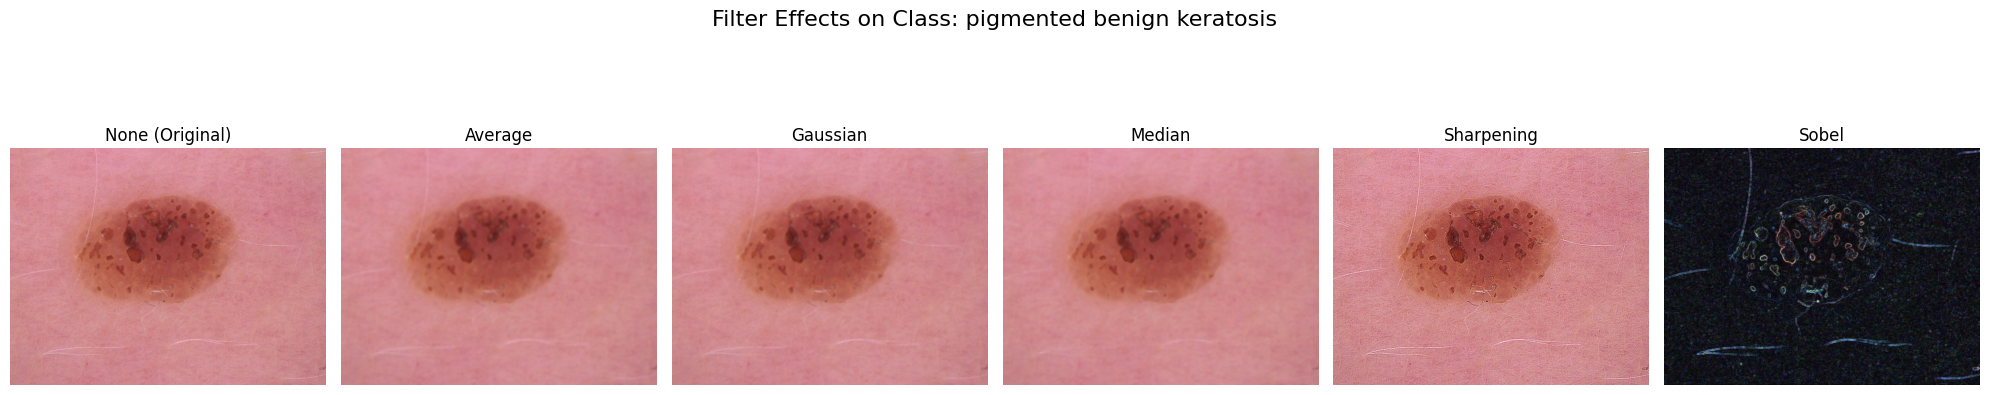

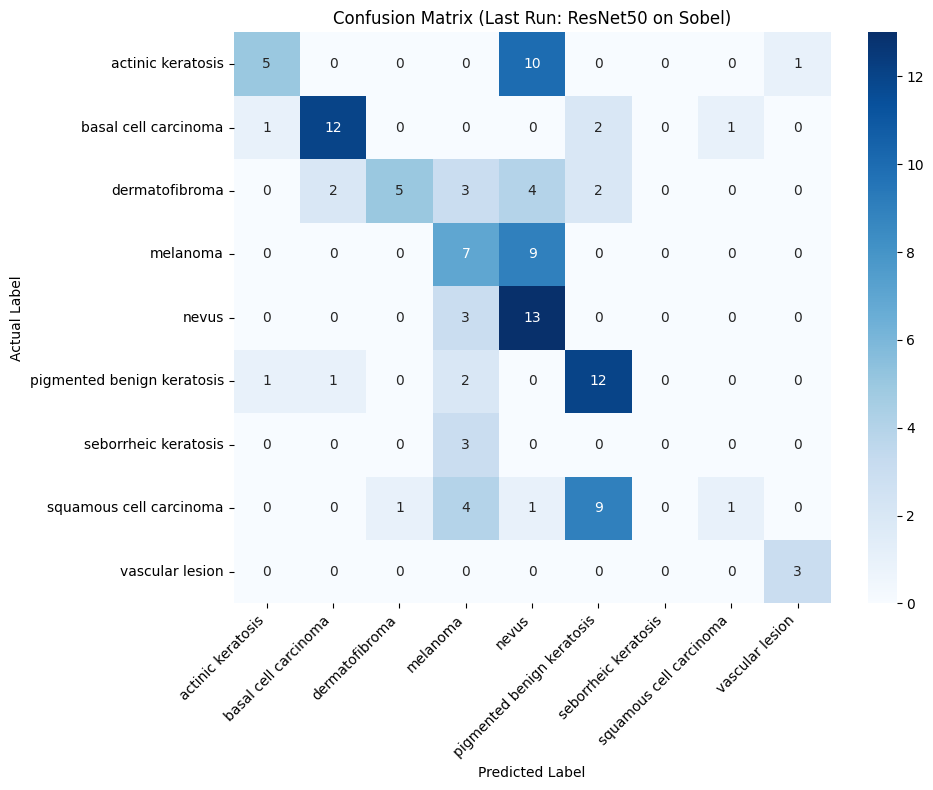

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import random

print("\n--- Generating Visualizations ---")

# 1. Filtered Image Examples Grid
def plot_filters(dataset):
    # Grab a random image from the raw, unfiltered dataset
    idx = random.randint(0, len(dataset)-1)
    orig_img, label = dataset[idx]

    filter_names = ['None (Original)', 'Average', 'Gaussian', 'Median', 'Sharpening', 'Sobel']
    fig, axes = plt.subplots(1, 6, figsize=(20, 5))

    for i, f_name in enumerate(filter_names):
        # Apply filter
        transform = ApplyFilter(filter_type='None' if f_name == 'None (Original)' else f_name)
        img_filtered = transform(orig_img)

        axes[i].imshow(img_filtered)
        axes[i].set_title(f_name)
        axes[i].axis('off')

    plt.suptitle(f"Filter Effects on Class: {class_names[label]}", fontsize=16)
    plt.tight_layout()
    plt.show()

# Use the raw dataset without the tensor transforms for visualization
raw_train_data = datasets.ImageFolder(os.path.join(base_dir, 'Train'))
plot_filters(raw_train_data)

# 2. Confusion Matrix (Using the last evaluated model from Section 6)
# all_labels and all_preds are still in memory from the last loop
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix (Last Run: {name} on {current_filter})")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()